# Sign Language Recognition (CNN Feature Extractor + LSTM Classifier)

This notebook trains a sign-language image classifier using:
- **CNN** layers for feature extraction
- **LSTM** layer for sequence modeling over spatial CNN features


In [13]:
import pathlib
import warnings

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
BASE_DIR = pathlib.Path('/kaggle/input/datasets/ash2703/handsignimages')
TRAIN_DIR = BASE_DIR / 'Train'
TEST_DIR = BASE_DIR / 'Test'

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
VAL_SPLIT = 0.20
EPOCHS = 20

assert TRAIN_DIR.exists(), f'Training directory not found: {TRAIN_DIR.resolve()}'

class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print('Train directory:', TRAIN_DIR.resolve())
print('Test directory:', TEST_DIR.resolve())
print('Detected training classes:', class_names)
print('Number of classes:', num_classes)

Train directory: /kaggle/input/datasets/ash2703/handsignimages/Train
Test directory: /kaggle/input/datasets/ash2703/handsignimages/Test
Detected training classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Number of classes: 24


In [4]:
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

def collect_files(root_dir, allowed_classes):
    file_paths = []
    labels = []

    for cls in allowed_classes:
        cls_dir = root_dir / cls
        if not cls_dir.exists():
            continue

        for p in cls_dir.rglob('*'):
            if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS:
                file_paths.append(str(p))
                labels.append(class_to_idx[cls])

    return np.array(file_paths), np.array(labels, dtype=np.int32)

train_files, train_labels = collect_files(TRAIN_DIR, class_names)
assert len(train_files) > 0, 'No training images found. Check your folder path and image files.'

x_train, x_val, y_train, y_val = train_test_split(
    train_files,
    train_labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=train_labels
)

test_files, test_labels = (np.array([]), np.array([], dtype=np.int32))
if TEST_DIR.exists():
    # Keep only test classes that exist in training classes to avoid label mismatch.
    test_files, test_labels = collect_files(TEST_DIR, class_names)

print(f'Total train images: {len(train_files):,}')
print(f'Train split: {len(x_train):,}')
print(f'Validation split: {len(x_val):,}')
print(f'Filtered test images (known classes only): {len(test_files):,}')

class_counts = {name: int(np.sum(train_labels == idx)) for idx, name in enumerate(class_names)}
print('Class distribution in full training set:', class_counts)

Total train images: 27,455
Train split: 21,964
Validation split: 5,491
Filtered test images (known classes only): 7,172
Class distribution in full training set: {'A': 1126, 'B': 1010, 'C': 1144, 'D': 1196, 'E': 957, 'F': 1204, 'G': 1090, 'H': 1013, 'I': 1162, 'K': 1114, 'L': 1241, 'M': 1055, 'N': 1151, 'O': 1196, 'P': 1088, 'Q': 1279, 'R': 1294, 'S': 1199, 'T': 1186, 'U': 1161, 'V': 1082, 'W': 1225, 'X': 1164, 'Y': 1118}


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.06),
    tf.keras.layers.RandomZoom(0.08),
], name='augmentation')

def decode_resize(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    return image, label

def make_dataset(file_paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(x_train, y_train, training=True)
val_ds = make_dataset(x_val, y_val, training=False)
test_ds = make_dataset(test_files, test_labels, training=False) if len(test_files) > 0 else None

print('Datasets ready.')

I0000 00:00:1775316658.749706      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready.


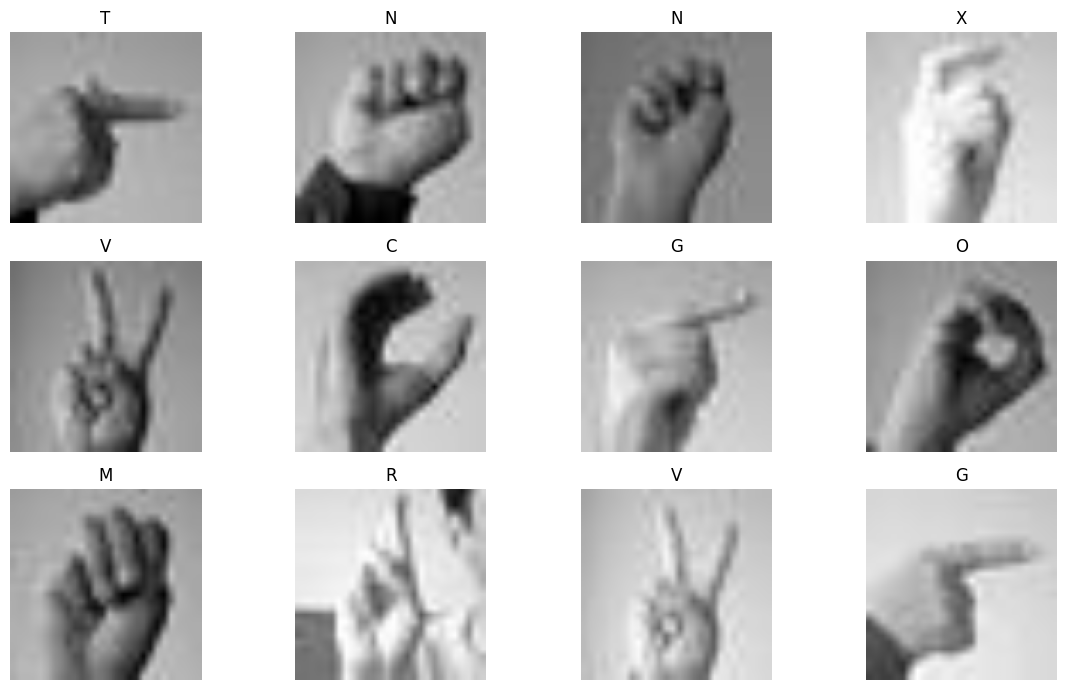

In [6]:
def show_batch(dataset, labels_map, n=12):
    images, labels = next(iter(dataset.take(1)))
    n = min(n, len(images))

    plt.figure(figsize=(12, 7))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.title(labels_map[int(labels[i])])
        plt.axis('off')
    plt.tight_layout()

show_batch(val_ds, class_names)

In [7]:
def build_cnn_lstm(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), classes=num_classes):
    inputs = tf.keras.Input(shape=input_shape, name='image_input')

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Convert spatial feature map (H, W, C) into a sequence (H*W, C) for LSTM.
    x = tf.keras.layers.Reshape((-1, int(x.shape[-1])), name='spatial_to_sequence')(x)

    x = tf.keras.layers.LSTM(128, dropout=0.3, name='lstm')(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(classes, activation='softmax', name='class_output')(x)
    return tf.keras.Model(inputs, outputs, name='cnn_lstm_sign_model')

model = build_cnn_lstm()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "cnn_lstm_sign_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_to_sequence (Reshape)   │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 607,064 (2.32 MB)

 Trainable params: 606,104 (2.31 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
checkpoint_path = 'best_sign_cnn_lstm.keras'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775316686.074277     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.0779 - loss: 3.0963
Epoch 1: val_accuracy improved from -inf to 0.09962, saving model to best_sign_cnn_lstm.keras
687/687 ━━━━━━━━━━━━━━━━━━━━ 69s 91ms/step - accuracy: 0.0780 - loss: 3.0961 - val_accuracy: 0.0996 - val_loss: 3.2112 - learning_rate: 0.0010
Epoch 2/20
686/687 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1972 - loss: 2.4843
Epoch 2: val_accuracy improved from 0.09962 to 0.10617, saving model to best_sign_cnn_lstm.keras
687/687 ━━━━━━━━━━━━━━━━━━━━ 52s 76ms/step - accuracy: 0.1973 - loss: 2.4839 - val_accuracy: 0.1062 - val_loss: 3.1611 - learning_rate: 0.0010
Epoch 3/20
686/687 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3373 - loss: 1.9001
Epoch 3: val_accuracy improved from 0.10617 to 0.43489, saving model to best_sign_cnn_lstm.keras
687/687 ━━━━━━━━━━━━━━━━━━━━ 52s 76ms/step - accuracy: 0.3374 - loss: 1.8998 - val_accuracy: 0.4349 - val_loss: 1.6128 - learning_rate: 0.0010
Epoch 4/20
686/687 ━━━━━━━━━━━━━━

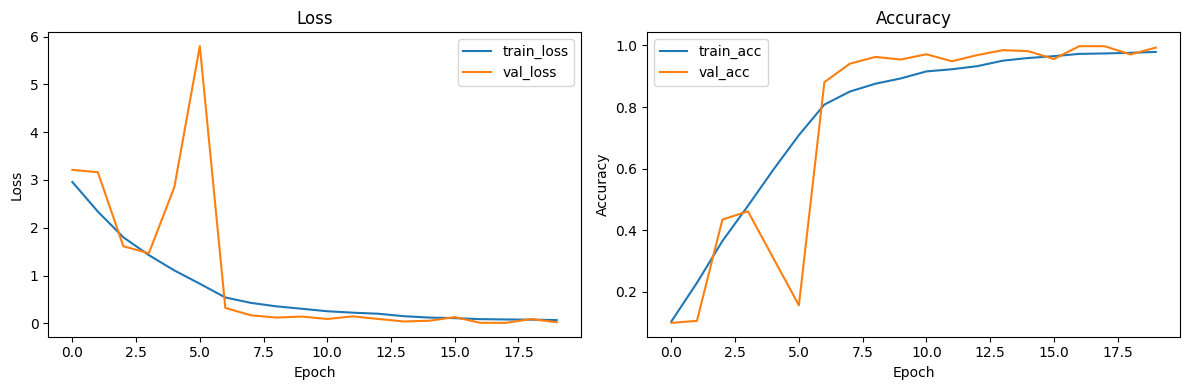

In [9]:
hist = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f'Validation loss: {val_loss:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')

if test_ds is not None:
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f'Test loss: {test_loss:.4f}')
    print(f'Test accuracy: {test_acc:.4f}')
else:
    print('No compatible test samples found in data/Test for the training classes.')

Validation loss: 0.0124
Validation accuracy: 0.9978
Test loss: 0.0638
Test accuracy: 0.9764


Classification report on test split:
              precision    recall  f1-score   support

           A     1.0000    0.9940    0.9970       331
           B     1.0000    0.9051    0.9502       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    0.9755    0.9876       245
           E     0.9980    1.0000    0.9990       498
           F     1.0000    1.0000    1.0000       247
           G     0.8892    0.9454    0.9164       348
           H     1.0000    0.9060    0.9507       436
           I     0.9965    0.9826    0.9895       288
           K     0.9970    0.9970    0.9970       331
           L     0.9952    1.0000    0.9976       209
           M     0.9494    1.0000    0.9740       394
           N     1.0000    0.9244    0.9607       291
           O     1.0000    1.0000    1.0000       246
           P     0.9971    0.9971    0.9971       347
           Q     1.0000    1.0000    1.0000       164
           R     0.9470    0.9931    0.9695 

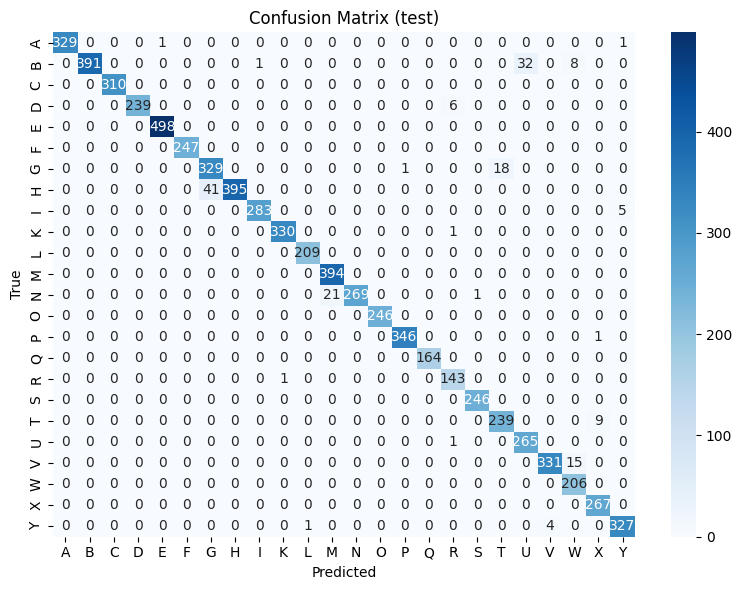

In [11]:
def get_predictions(model, dataset):
    y_true, y_pred = [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.tolist())

    return np.array(y_true), np.array(y_pred)

eval_ds = test_ds if test_ds is not None else val_ds
eval_name = 'test' if test_ds is not None else 'validation'

y_true, y_pred = get_predictions(model, eval_ds)

print(f'Classification report on {eval_name} split:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix ({eval_name})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

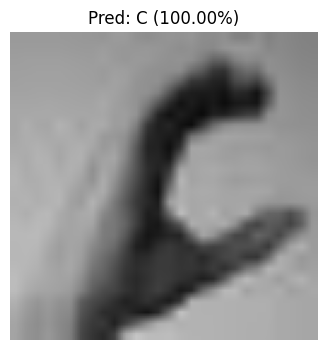

Sample image path: /kaggle/input/datasets/ash2703/handsignimages/Test/C/5064_C.jpg


In [12]:
def predict_single_image(model, image_path):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    probs = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return class_names[pred_idx], float(probs[pred_idx]), image

sample_pool = test_files if len(test_files) > 0 else x_val
sample_path = str(np.random.choice(sample_pool))

pred_class, confidence, sample_img = predict_single_image(model, sample_path)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.axis('off')
plt.title(f'Pred: {pred_class} ({confidence:.2%})')
plt.show()

print('Sample image path:', sample_path)